# Trabajo Semanal 1
### Joaquin Ezequiel Alvarez Olmedo

Se tienen los siguientes circuitos pasabanda cuyos inductores deben ser reemplazados por un GIC de Antoniou:

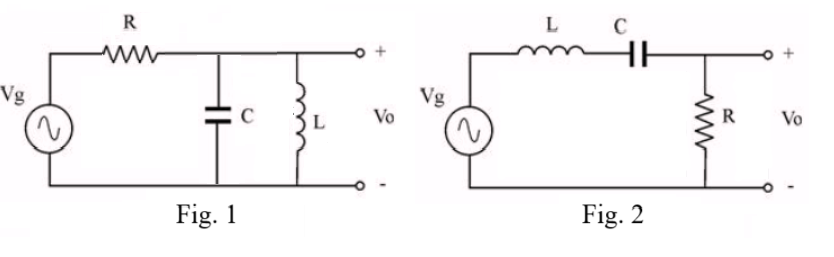
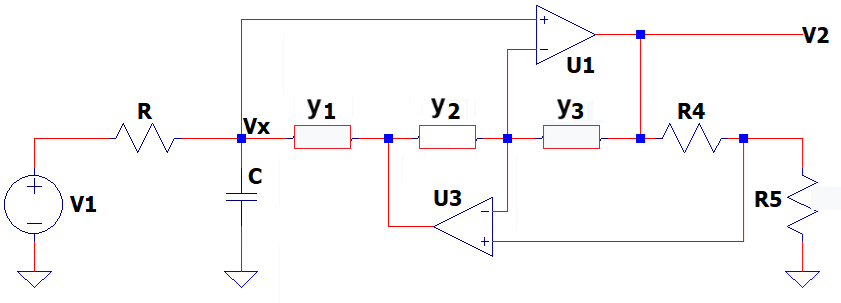

Primero debemos reemplazar las admitancias del circuito por R y C convenientemente tal que la impedancia de entrada que presente se asemeje a la de un inductor.

Resolvemos el circuito mediante metodo de nodos, armamos la matriz admitancia y obtenemos Vi e I1 mediante las determinantes de las submatrices:

1) $ V_i(Y_1) - V_a(Y_1) = I_1$
2) $ V_i(Y_2 + Y_3) - V_a(Y_2) - V_b(Y_3) = 0 $
3) $ V_i(Y_4 + Y_5) - V_b(Y_4) = 0 $

Para simplificar la demostracion empleamos codigo de la documentacion de la libreria pytc2. Vemos que los terminos de las matrices coinciden con las ecuaciones planteadas.

In [ ]:
import sympy as sp
from pytc2.general import a_equal_b_latex_s, print_latex, symbfunc2tf
from pytc2.sistemas_lineales import bodePlot

I1, V1, V2, V3, V4, V5 = sp.symbols("I1, V1, V2, V3, V4, V5")
Y1, Y2, Y3, Y4, Y5, As = sp.symbols("Y1, Y2, Y3, Y4, Y5, As")
G, C, wt, w0 = sp.symbols("G, C, wt, w0", real = True, posistive = True) 

aa = sp.solve([ 
                V1*Y1 - V2*Y1 - I1, 
                -V2*Y2 + V1*(Y2+Y3) -V3*Y3,
                -V3*Y4 + V1*(Y4+Y5)
                ], 
                [V1, V2, V3])
Z1 = aa[V1]/I1

print_latex(a_equal_b_latex_s('Z_1 = \\frac{V_1}{I_1}', Z1))

: 

$ Z_in = S * Leq $

Para "colocar" una S en el numerador hagamos que alguna de las admitancias del numerador sea un capacitor. Se sabe que $ Y_4 $ es una resistencia basandonos en el esquema del circuito pero se puede deducir de la siguiente forma:

$ V_b = V_o $ Reemplazamos en la ecuación 3

3) $ V_i(Y_4 + Y_5) - V_o(Y_4) = 0 $
$ V_i = V_o * \frac{Y_4}{Y_4 + Y_5} $
$ V_i = V_o * \frac{R_5}{R_4 + R_5} $

Vemos que nos queda un divisor resistivo y por lo tanto:

$ Y_2 = C_2 , Y_4 = R_4 $

Las demas admitancias las dejamos como resistencias. De este modo la impedancia de entrada queda:

$ Z_in = \frac{SC_2 * 1/R_4}{1/R_1 * 1/R_3 * 1/R_5} $

Por convencion R4 y R5 seran iguales ya que podemos generar 2 salidas tales que por una salgamos con modulo de transferencia unitario y por la otra el doble.

Ahora si queremos que la inductancia equivalente sea unitaria el resto de las resistencias deben ser iguales a R... es como si necesitasemos que este todo normalizado. Normalizamos tambien C = 1.

$ Z_in = \frac{S * 1}{1 * 1 * 1} = S * Leq $ 

Entonces $ Leq = 1 $

<br>
<br>
<br>

Ahora analicemos la transferencia del pasabanda teniendo en cuenta que ahora la el inductor fue reemplazado por el GIC. Retomando del analisis previo podemos deducir la transferencia del GIC:

$ V_i = V_o * \frac{R_5}{R_4 + R_5} $

$ T(S) = \frac{V_o}{V_i} = \frac{R_5}{R_4 + R_5} = 1 + \frac{R_5}{R_4}$

Si R4 = R5 entonces T(S) = 2 si salimos por V2. Si saliesemos por R5 entonces la transferencia es unitaria. El GIC añade un "K" a la transferencia de todo el circuito.

$ T(S) = \frac{V_2(S)}{V_1(S)} = \frac{2 * V_x(S)}{V_1(S)} = \frac{2 * I(S) * (Z_C // Z_L)}{I(S) * (R + (Z_C // Z_L))} $

Luego de un poco de algebra llegamos a la siguiente expresion

$ T(S) = 2 * \frac{S * L_eq}{S^2 * RCL_eq + S * L_eq + R} = 2* \frac{S * 1/RC}{S^2 + S * 1/RC + 1/CL_eq} $

Coincide con la forma de un pasabanda

$ T(S) = 2 * \frac{S * \omega_0/Q}{S^2 + S * \omega_0/Q + \omega_0^2} $ 

1) $ \omega_0 = \sqrt{\frac{1}{CL_eq}} $
2) $ Q = R * \sqrt{\frac{C}{L_eq}} $
3) $ \frac{\omega_0}{Q} = \frac{1}{RC} $
4) $ K = 2 $

Con esta expresion ahora es sencillo determinar que componentes se necesitan para obtener $ \omega_0 $ y $ Q $ determinados.

<br>
<br>
<br>

Si ahora quisiesemos $ f_0 = 10KHz $ y $ Q = 20 $ recurrimos a las expresiones obtenidas de nuestros parametros de diseño. Como añadido para este caso se tiene como restriccion el uso de capacitores de entre $ 1nF $ y $ 100nF $. Proponemos $ C = 4,7nF $

3) $ \frac{20\pi*KHz}{20} = \frac{1}{R * 4,7nF} $

$ R = 67,7K\Omega \approx 68K\Omega $

1) $ 20\pi*KHz = \sqrt{\frac{1}{4,7nF * L_eq}} $

$ L_eq = 53,9mHy $

Mantenemos R4 = R5 y proponemos que sean de $ 1K\Omega $

$ L_eq = C_2 * R_1 * R_3 = 53,9mHy $

Proponemos $ C_2 = 10nF $

$ R_1 * R_3 = 5,39M\Omega^2 $

Si ahora hacemos que R1 y R3 sean iguales:

$ R_1 = R_3 = 2,3K\Omega \approx 2,2K\Omega $

<br>
<br>
<br>

Verificamos con valores comerciales de los componentes para ver que tan preciso es nuestro diseño:

$ L_eq = 10nF * 2,2K\Omega * 2,2K\Omega = 48,4mHy $

$ f_0 = \sqrt{\frac{1}{4,7nF * 48,4mHy}} * \frac{1}{2\pi} \approx 10,5KHz $

$ 20 = 68K\Omega * \sqrt{\frac{4,7nF}{48,4mHy}} \approx 21,19 $

Los parametros se asemejan a los deseados.

<br>
<br>
<br>

Ahora simulamos la transferencia y levantamos los graficos

In [ ]:
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq
from scipy import signal as sig

# Configuración de gráficos

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80
fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

fig_id, axes_hdl = bodePlot(symbfunc2tf(Z1num), filter_description='$\omega_t = {:d}$'.format(100), fig_id=1)


# Pasabanda con Q = 20, f0 = 10kHz

Q = 20

w0 = 20000 * math.pi

num = np.array([ w0 / Q, 0 ])
den = np.array([ 1., w0 / Q, w0**2 ])

pretty_print_bicuad_omegayq(num,den)

H1 = sig.TransferFunction( num, den )
_ = analyze_sys([H1], sys_name='pasabanda Q={:3.20}'.format(Q))